#### Dummy Coding

In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [27]:
# Build city rent dataset
df = pd.DataFrame({'City': ['SF', 'SF', 'SF', 'NYC', 'NYC', 'NYC', 'Seattle', 'Seattle', 'Seattle'],
                   'Rent': [3999, 4000, 4001, 3499, 3500, 3501, 2499, 2500, 2501]})
df

,City,Rent
0,SF,3999
1,SF,4000
2,SF,4001
3,NYC,3499
4,NYC,3500
5,NYC,3501
6,Seattle,2499
7,Seattle,2500
8,Seattle,2501


In [28]:
# Create dummy variables
one_hot_df = pd.get_dummies(df, prefix=['city'], drop_first=True)
one_hot_df

,Rent,city_SF,city_Seattle
0,3999,True,False
1,4000,True,False
2,4001,True,False
3,3499,False,False
4,3500,False,False
5,3501,False,False
6,2499,False,True
7,2500,False,True
8,2501,False,True


In [14]:
# Build linear regression model
# Display intercept and coefficient variables
lin_reg = LinearRegression()
lin_reg.fit(one_hot_df[['city_SF', 
                        'city_Seattle']], one_hot_df['Rent'])
print(f'Coefficient: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')
                        

Coefficient: [  500. -1000.]
Intercept: 3500.0000000000005


In [16]:
# Assign dummy coding weights (coefficients) and intercept
w2 = lin_reg.coef_
b2 = lin_reg.intercept_

#### Effect Coding

In [80]:
# Create copy
effect_df = one_hot_df.copy()

# Change the SF and Seattle columns to float
effect_df[['city_SF','city_Seattle']] = effect_df[['city_SF','city_Seattle']].astype(float)
effect_df

,Rent,city_SF,city_Seattle
0,3999,1.0,0.0
1,4000,1.0,0.0
2,4001,1.0,0.0
3,3499,0.0,0.0
4,3500,0.0,0.0
5,3501,0.0,0.0
6,2499,0.0,1.0
7,2500,0.0,1.0
8,2501,0.0,1.0


In [81]:
# Search for items that have both SF and Seattle values of 0
BM = effect_df[(effect_df['city_SF']==0) & (effect_df['city_Seattle']==0)].index

# For each index value in BM update the SF and Seattle values to -1
for i in BM:
    effect_df.loc[i, 'city_SF']=-1
    effect_df.loc[i, 'city_Seattle']=-1
effect_df

,Rent,city_SF,city_Seattle
0,3999,1.0,0.0
1,4000,1.0,0.0
2,4001,1.0,0.0
3,3499,-1.0,-1.0
4,3500,-1.0,-1.0
5,3501,-1.0,-1.0
6,2499,0.0,1.0
7,2500,0.0,1.0
8,2501,0.0,1.0


In [88]:
# Create the X and y arrays for a model
X = effect_df.drop(['Rent'], axis=1)
y = effect_df['Rent']

In [89]:
lin_reg.fit(X, y)
print(f'Coefficient: {lin_reg.coef_}')
print(f'Intercept: {lin_reg.intercept_}')

Coefficient: [ 666.66666667 -833.33333333]
Intercept: 3333.3333333333335


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.4, color_codes=True)

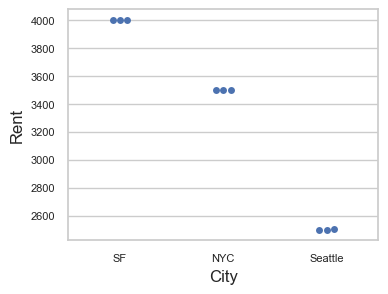

In [104]:
plt.figure(figsize=(4,3))
ax = sns.swarmplot(x='City', y='Rent', data=df)
ax.tick_params(labelsize=8)
ax.set_xlabel('City',fontsize=12)
ax.set_ylabel('Rent',fontsize=12)
plt.show()

#### Feature Hashing

In [106]:
import json
from langdetect import detect, LangDetectException

# Open a json file in read mode
f = open('yelp_academic_dataset_review.json','r', encoding='utf-8')
js = []

# Append the first 10,000 rows into a dataset if the text is English
i = 0
while i < 10000:
    jrl = json.loads(f.readline())
    if detect(jrl['text']) =='en':
        #print(jrl)
        js.append(jrl)
        i +=1    
f.close()
review_df = pd.DataFrame(js)

# Return the shape
review_df.shape

(10000, 9)

In [107]:
# Display the unique business id values
m = len(review_df['business_id'].unique())
print(m)

3932


In [146]:
# Feature hashing of the business_id column
from sklearn.feature_extraction import FeatureHasher
h = FeatureHasher(n_features=m, input_type='string')
f = h.transform([[x] for x in review_df['business_id']])

In [147]:
# Show the first 3 rows
f.toarray()[:3]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [148]:
# Compare the size of the original series and the hashed array
from sys import getsizeof

print('Our pandas Series, in bytes: ', getsizeof(review_df['business_id']))
print('Our hashed numpy array, in bytes: ', getsizeof(f))

Our pandas Series, in bytes:  710164
Our hashed numpy array, in bytes:  48


#### Bin Counting

In [150]:
#df = pd.read_csv('train_subset.csv')

In [ ]:
def click_counting(x, bin_column):
    clicks = pd.Series(x[x['click'] > 0][bin_column].value_counts(), name='clicks')
    no_clicks = pd.Series(x[x['click'] < 1][bin_column].value_counts(), name='no_clicks')
    
    counts = pd.DataFrame([clicks,no_clicks]).T.fillna('0')
    counts['total'] = counts['clicks'].astype('int64') + counts['no_clicks'].astype('int64')
    
    return counts

def bin_counting(counts):
    counts['N+'] = counts['clicks'].astype('int64').divide(counts['total'].astype('int64'))
    counts['N-'] = counts['no_clicks'].astype('int64').divide(counts['total'].astype('int64'))
    counts['log_N+'] = counts['N+'].divide(counts['N-'])

#    If we wanted to only return bin-counting properties, we would filter here
    bin_counts = counts.filter(items= ['N+', 'N-', 'log_N+'])
    return counts, bin_counts

In [ ]:
# bin counts example: device_id
bin_column = 'device_id'
device_clicks = click_counting(df.filter(items= [bin_column, 'click']), bin_column)
device_all, device_bin_counts = bin_counting(device_clicks)

In [ ]:
device_all.sort_values(by = 'total', ascending=False).head(4)

In [ ]:
# We can see how this can change model evaluation time by comparing raw vs. bin-counting size
from sys import getsizeof

print('Our pandas Series, in bytes: ', getsizeof(df.filter(items= ['device_id', 'click'])))
print('Our bin-counting feature, in bytes: ', getsizeof(device_bin_counts))